# Concentrated-map CPU/GPU grouper stress analysis

This notebook compares one-map, one-family, and all-map candidate layouts at equal decoded candidate counts. Set `PIRATE_CONCENTRATED_MAP_GROUPER_RESULTS` before starting Jupyter to select a non-default result bundle.

In [1]:
import csv
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

def find_repository_root():
    configured = os.environ.get('PIRATE_REPOSITORY_ROOT')
    starts = [Path(configured).expanduser()] if configured else []
    starts.append(Path.cwd())
    for start in starts:
        for candidate in (start.resolve(), *start.resolve().parents):
            if (candidate / 'peakfinder_tests/benchmark_concentrated_map_grouper_timing.py').is_file():
                return candidate
    raise FileNotFoundError('cannot locate the PIRATE repository root')

REPOSITORY_ROOT = find_repository_root()
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))
from peakfinder_tests import benchmark_concentrated_map_grouper_timing as benchmark

configured = os.environ.get('PIRATE_CONCENTRATED_MAP_GROUPER_RESULTS')
RESULTS_DIR = (
    Path(configured).expanduser() if configured
    else REPOSITORY_ROOT / 'peakfinder_tests/results_concentrated_map_grouper_timing'
).resolve()
csv_path = RESULTS_DIR / 'trials.csv'
metadata_path = RESULTS_DIR / 'metadata.yaml'
if not csv_path.is_file() or not metadata_path.is_file():
    raise FileNotFoundError(f'incomplete result bundle: {RESULTS_DIR}')
with csv_path.open(newline='', encoding='utf-8') as stream:
    reader = csv.DictReader(stream)
    if tuple(reader.fieldnames or ()) != benchmark.CSV_FIELDS:
        raise ValueError('trials.csv schema differs from the benchmark')
    rows = list(reader)
with metadata_path.open(encoding='utf-8') as stream:
    metadata = yaml.safe_load(stream) or {}
if metadata.get('schema_name') != benchmark.SCHEMA_NAME or metadata.get('schema_version') != benchmark.SCHEMA_VERSION:
    raise ValueError('unsupported concentrated-map result schema')
if metadata.get('csv', {}).get('fields') != list(benchmark.CSV_FIELDS):
    raise ValueError('metadata CSV schema differs from the benchmark')
if int(metadata.get('csv', {}).get('rows', -1)) != len(rows):
    raise ValueError('metadata row count differs from trials.csv')
print(f'Loaded {len(rows)} rows from {RESULTS_DIR}')
print(f"GPU: {metadata['environment']['gpu']['model']}")


Loaded 105 rows from /home/mtrudu/src/pirate-updated/peakfinder_tests/results_concentrated_map_grouper_timing
GPU: NVIDIA A40


In [2]:
layouts = tuple(metadata['workload']['layouts'])
counts = tuple(int(value) for value in metadata['workload']['hot_pixel_counts'])
repeats = int(metadata['workload']['repeats'])
expected_keys = {(layout, count, repeat) for layout in layouts for count in counts for repeat in range(repeats)}
actual_keys = {(row['layout'], int(row['hot_pixel_count']), int(row['repeat'])) for row in rows}
if actual_keys != expected_keys or len(rows) != len(expected_keys):
    raise ValueError('trials.csv does not contain the exact requested grid')

numeric_fields = (
    'hot_pixel_count', 'selected_map_occupancy_percent', 'raw_candidate_count',
    'decoded_candidate_count', 'partition_count', 'largest_partition',
    'peakfinder_wall_ms', 'decoder_wall_ms', 'gpu_grouper_wall_ms',
    'gpu_retained_candidates', 'gpu_grouped_events', 'gpu_timed_out',
    'gpu_complete', 'exact_parity_verified',
)
for line_number, row in enumerate(rows, start=2):
    for field in numeric_fields:
        value = float(row[field])
        if not np.isfinite(value) or value < 0:
            raise ValueError(f'trials.csv:{line_number}:{field} is invalid')
    hot = int(row['hot_pixel_count'])
    if int(row['raw_candidate_count']) != hot or int(row['decoded_candidate_count']) != hot:
        raise ValueError(f'trials.csv:{line_number}: candidate conservation failed')
    complete = bool(int(row['gpu_complete']))
    timed_out = bool(int(row['gpu_timed_out']))
    if complete == timed_out:
        raise ValueError(f'trials.csv:{line_number}: GPU status is inconsistent')
    if complete and int(row['gpu_retained_candidates']) != hot:
        raise ValueError(f'trials.csv:{line_number}: complete GPU result lost candidates')
    if row['cpu_status'] == 'completed':
        cpu_ms = float(row['cpu_grouper_wall_ms'])
        if not np.isfinite(cpu_ms) or cpu_ms < 0:
            raise ValueError(f'trials.csv:{line_number}: CPU timing is invalid')
        if complete and int(row['exact_parity_verified']) != 1:
            raise ValueError(f'trials.csv:{line_number}: completed pair lacks parity')
    elif row['cpu_status'] != 'skipped_limit':
        raise ValueError(f'trials.csv:{line_number}: unknown CPU status')
print('Exact workload grid and all recorded invariants validated.')


Exact workload grid and all recorded invariants validated.


In [3]:
COLORS = {'single_map': 'tab:red', 'single_family': 'tab:orange', 'all_maps': 'tab:blue'}
LABELS = {'single_map': 'One map', 'single_family': 'One family', 'all_maps': 'All maps'}

def selected(layout, count, *, complete_only=False, cpu_only=False):
    result = [row for row in rows if row['layout'] == layout and int(row['hot_pixel_count']) == count]
    if complete_only:
        result = [row for row in result if int(row['gpu_complete']) == 1]
    if cpu_only:
        result = [row for row in result if row['cpu_status'] == 'completed']
    return result

def median_curve(layout, field, *, complete_only=False, cpu_only=False):
    points = []
    for count in counts:
        values = [float(row[field]) for row in selected(layout, count, complete_only=complete_only, cpu_only=cpu_only) if row[field] != '']
        if values:
            points.append((count, float(np.median(values)), float(np.quantile(values, 0.25)), float(np.quantile(values, 0.75))))
    return np.asarray(points, dtype=float)


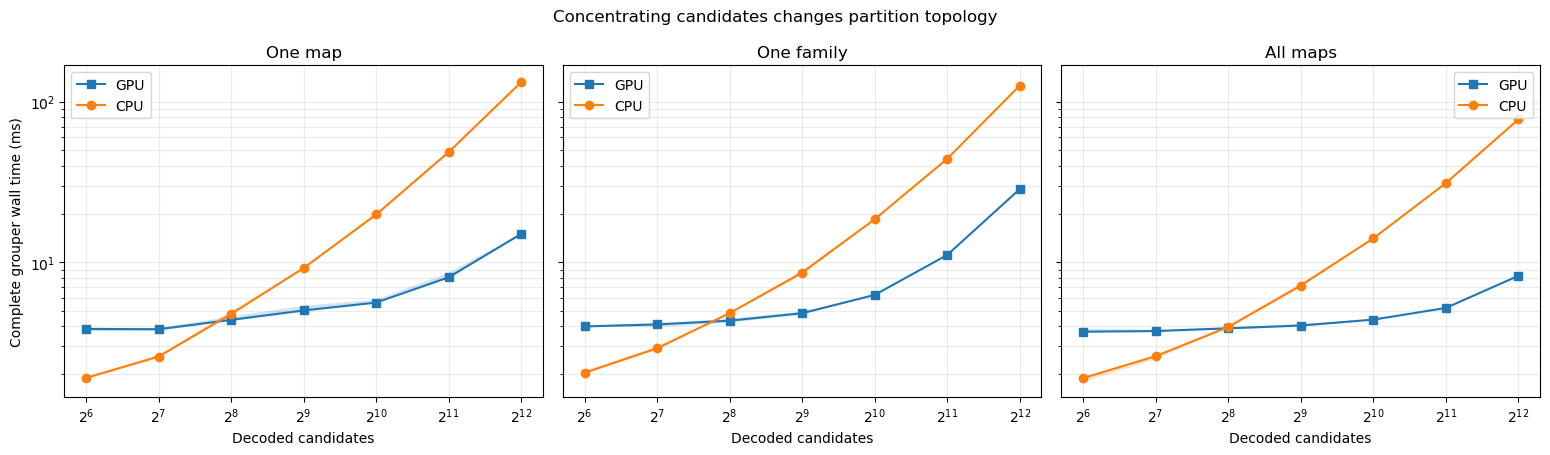

In [4]:
fig, axes = plt.subplots(1, len(layouts), figsize=(5.2 * len(layouts), 4.6), sharey=True, squeeze=False)
for axis, layout in zip(axes[0], layouts):
    gpu_curve = median_curve(layout, 'gpu_grouper_wall_ms', complete_only=True)
    cpu_curve = median_curve(layout, 'cpu_grouper_wall_ms', cpu_only=True)
    if gpu_curve.size:
        axis.plot(gpu_curve[:, 0], gpu_curve[:, 1], marker='s', label='GPU')
        axis.fill_between(gpu_curve[:, 0], gpu_curve[:, 2], gpu_curve[:, 3], alpha=0.2)
    if cpu_curve.size:
        axis.plot(cpu_curve[:, 0], cpu_curve[:, 1], marker='o', label='CPU')
        axis.fill_between(cpu_curve[:, 0], cpu_curve[:, 2], cpu_curve[:, 3], alpha=0.2)
    axis.set_xscale('log', base=2)
    axis.set_yscale('log')
    axis.set_title(LABELS[layout])
    axis.set_xlabel('Decoded candidates')
    axis.grid(True, which='both', alpha=0.25)
    axis.legend()
axes[0, 0].set_ylabel('Complete grouper wall time (ms)')
fig.suptitle('Concentrating candidates changes partition topology')
fig.tight_layout()


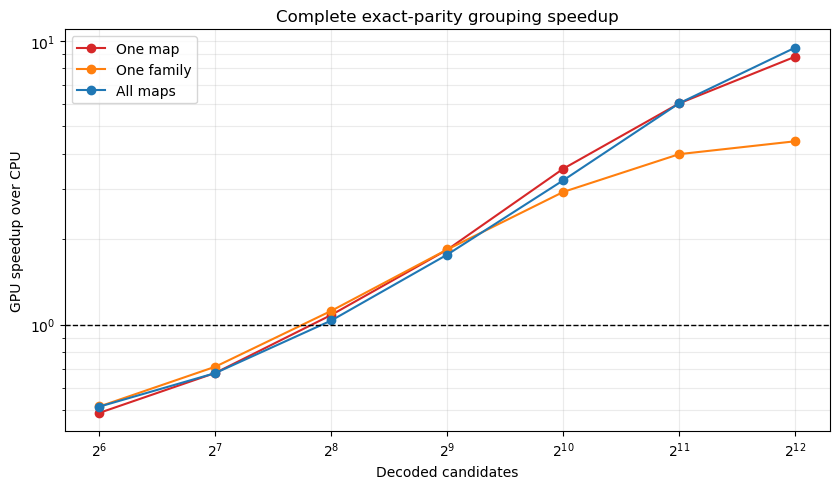

In [5]:
fig, axis = plt.subplots(figsize=(8.5, 5.0))
for layout in layouts:
    curve = median_curve(layout, 'gpu_over_cpu_speedup', complete_only=True, cpu_only=True)
    if curve.size:
        axis.plot(curve[:, 0], curve[:, 1], marker='o', color=COLORS[layout], label=LABELS[layout])
axis.axhline(1.0, color='black', linewidth=1, linestyle='--')
axis.set_xscale('log', base=2)
axis.set_yscale('log')
axis.set_xlabel('Decoded candidates')
axis.set_ylabel('GPU speedup over CPU')
axis.set_title('Complete exact-parity grouping speedup')
axis.grid(True, which='both', alpha=0.25)
axis.legend()
fig.tight_layout()


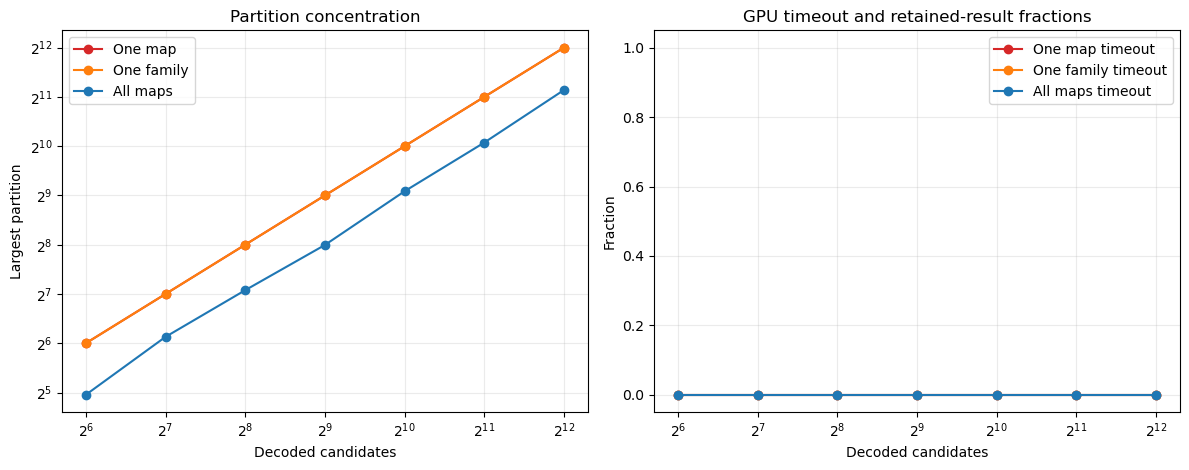

In [6]:
fig, (partition_axis, timeout_axis) = plt.subplots(1, 2, figsize=(12.0, 4.8))
for layout in layouts:
    x, largest, timeout_fraction, retained_fraction = [], [], [], []
    for count in counts:
        group = selected(layout, count)
        if not group:
            continue
        x.append(count)
        largest.append(np.median([float(row['largest_partition']) for row in group]))
        timeout_fraction.append(np.mean([float(row['gpu_timed_out']) for row in group]))
        retained_fraction.append(np.median([float(row['gpu_retained_candidates']) / count for row in group]))
    partition_axis.plot(x, largest, marker='o', color=COLORS[layout], label=LABELS[layout])
    timeout_axis.plot(x, timeout_fraction, marker='o', color=COLORS[layout], label=f'{LABELS[layout]} timeout')
    if any(timeout_fraction):
        timeout_axis.plot(x, retained_fraction, marker='x', linestyle='--', color=COLORS[layout], label=f'{LABELS[layout]} retained')
partition_axis.set_xscale('log', base=2)
partition_axis.set_yscale('log', base=2)
partition_axis.set_xlabel('Decoded candidates')
partition_axis.set_ylabel('Largest partition')
partition_axis.set_title('Partition concentration')
timeout_axis.set_xscale('log', base=2)
timeout_axis.set_ylim(-0.05, 1.05)
timeout_axis.set_xlabel('Decoded candidates')
timeout_axis.set_ylabel('Fraction')
timeout_axis.set_title('GPU timeout and retained-result fractions')
for axis in (partition_axis, timeout_axis):
    axis.grid(True, which='both', alpha=0.25)
    axis.legend()
fig.tight_layout()
